In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing_dataset.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [3]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
df.isnull().mean()*100 # observing % of missing values in each column

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

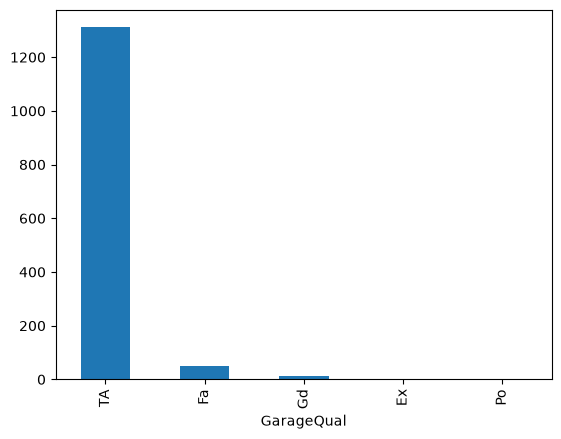

In [5]:
df['GarageQual'].value_counts().plot(kind='bar')
plt.show()

In [6]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: str

In [7]:
# for displaying specific columns when our conidion is true, we use this.
df.loc[df['GarageQual'] == 'Gd', ['SalePrice', 'FireplaceQu']] # gives all the rows of the df where the GarageQual is Gd.

,SalePrice,FireplaceQu
9,118000,TA
172,239000,TA
290,233230,Gd
438,90350,Gd
568,316600,Gd
583,325000,Gd
841,157500,Po
842,174900,NaN
1159,185000,TA
1281,180000,TA


In [8]:
# for displaying df or all columns when our condition is true, we use this.
df[df['GarageQual']=='Gd']# gives all the rows of the df where the GarageQual is Gd. 

,FireplaceQu,GarageQual,SalePrice
9,TA,Gd,118000
172,TA,Gd,239000
290,Gd,Gd,233230
438,Gd,Gd,90350
568,Gd,Gd,316600
583,Gd,Gd,325000
841,Po,Gd,157500
842,NaN,Gd,174900
1159,TA,Gd,185000
1281,TA,Gd,180000


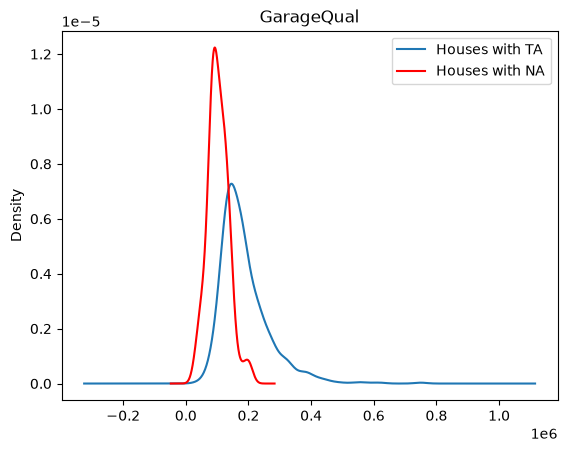

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)

#This plots the SalePrice distribution for houses whose garage quality is TA.
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax) 

#This plots the SalePrice distribution for houses whose garage quality is missing or null.
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')
plt.show()

In [10]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [11]:
df.fillna({'GarageQual':'TA'},inplace=True) # filling missing values with mode 

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


<Axes: xlabel='GarageQual'>

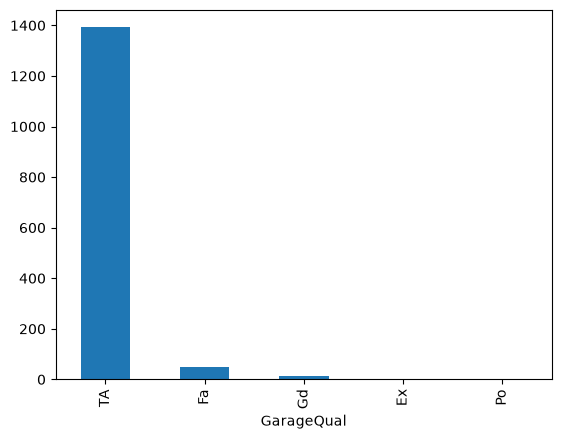

In [12]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

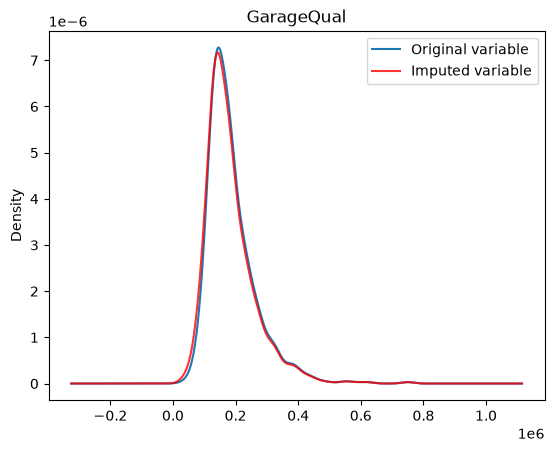

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax) # original 'GarargeQual'

# distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red',alpha=0.8)

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual') # both curves are almost identical because there is little amount of missing values. so even after inputing missing values with 'TA', the distribution remains almost similar.

<Axes: xlabel='FireplaceQu'>

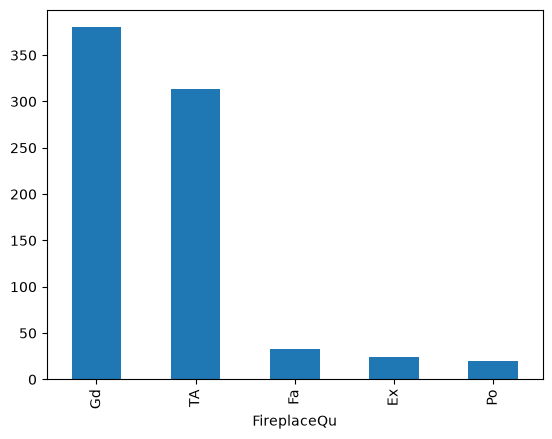

In [14]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [15]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: str

Text(0.5, 1.0, 'FireplaceQu')

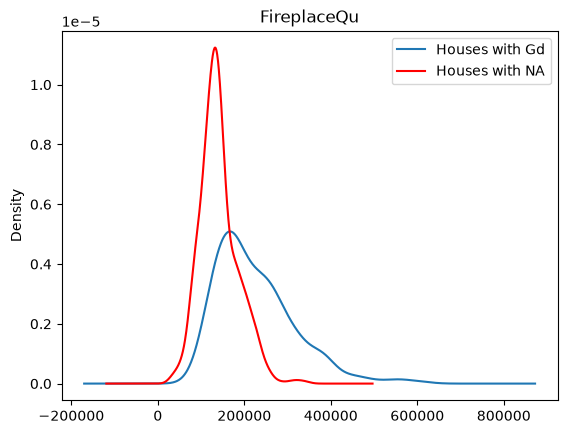

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [17]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [26]:
df.fillna({'FireplaceQu':'Gd'},inplace=True)

,FireplaceQu,GarageQual,SalePrice
0,Gd,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,Gd,TA,142125


<Axes: xlabel='FireplaceQu'>

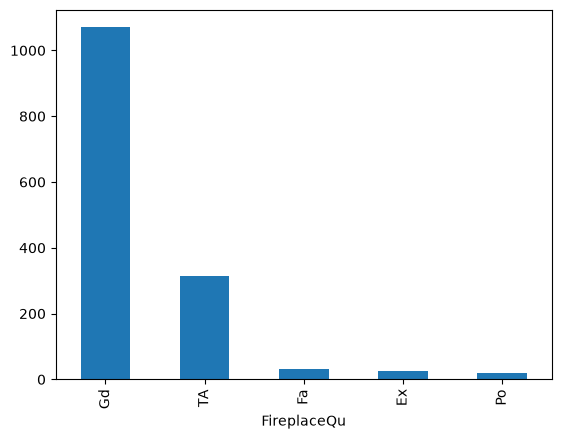

In [27]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

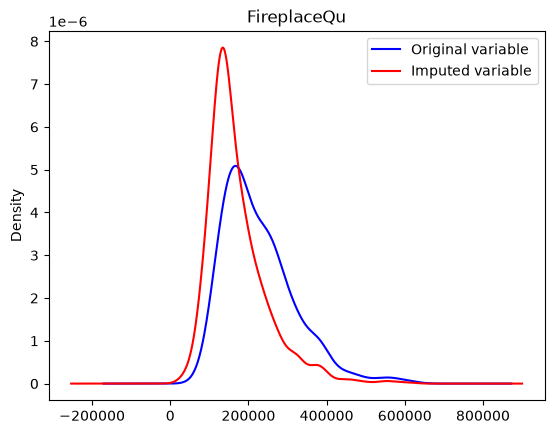

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax,color='blue')

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

# imputing missing categorical values in sklearn using 'most_frequent' strategy

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [30]:
from sklearn.impute import SimpleImputer

In [31]:
imputer = SimpleImputer(strategy='most_frequent')

In [33]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

In [34]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)